<a href="https://colab.research.google.com/github/naqia88/flood-extent-mapping-sar-deep-learning/blob/main/Flood_Extent_Mapping_Using_SAR_Satellite_Imagery_and_Deep_Learning_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Requirements

In [ ]:
# Requirements
# segmentation-models-pytorch
# rasterio
# torch
# scikit-learn
# matplotlib
# huggingface_hub
# geopandas (optional)

# Install

In [ ]:
!pip -q install rasterio segmentation-models-pytorch timm albumentations scikit-learn pandas matplotlib seaborn tqdm

# Imports and configuration

In [ ]:
import os,glob,random,warnings,numpy as np,pandas as pd,matplotlib.pyplot as plt,rasterio,torch,torch.nn as nn,torch.nn.functional as F,segmentation_models_pytorch as smp
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,f1_score,jaccard_score,confusion_matrix
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED)
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE=256
BATCH_SIZE=8
EPOCHS=15
LR=1e-4
NUM_WORKERS=2
print("Device:",DEVICE)

Device: cuda


# Download dataset

In [ ]:
!pip install -U huggingface_hub

In [ ]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="blumenstiel/Sen1Floods11",
    filename="sen1floods11_v1_1.tar.gz",
    repo_type="dataset"
)

print(file_path)

/root/.cache/huggingface/hub/datasets--blumenstiel--Sen1Floods11/snapshots/0aa4d22937f726bbf699f902b59026a9e3f75c52/sen1floods11_v1_1.tar.gz


In [ ]:
import tarfile
import os

extract_dir = "/content/Sen1Floods11"

os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(file_path, "r:gz") as tar:
    tar.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset extracted to: /content/Sen1Floods11


# Inspect dataset

In [ ]:
# Cell — Define dataset path

DATASET_PATH = "/content/Sen1Floods11"
import os
print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

Dataset path: /content/Sen1Floods11
Exists: True


In [ ]:
# Inspect dataset structure

for root, dirs, files in os.walk(DATASET_PATH):
    print(root, len(files))
    if files:
        print(files[:5])

/content/Sen1Floods11 0
/content/Sen1Floods11/sen1floods11_v1.1 1
['Sen1Floods11_Metadata.geojson']
/content/Sen1Floods11/sen1floods11_v1.1/data 0
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM 446
['USA_348639_DEM.tif', 'Somalia_699062_DEM.tif', 'Ghana_167233_DEM.tif', 'Nigeria_81933_DEM.tif', 'India_769408_DEM.tif']
/content/Sen1Floods11/sen1floods11_v1.1/data/S1OtsuLabelHand 446
['Mekong_424793_S1OtsuLabelHand.tif', 'USA_994009_S1OtsuLabelHand.tif', 'Somalia_886726_S1OtsuLabelHand.tif', 'USA_375183_S1OtsuLabelHand.tif', 'Sri-Lanka_85652_S1OtsuLabelHand.tif']
/content/Sen1Floods11/sen1floods11_v1.1/data/LabelHand 446
['Spain_2938657_LabelHand.tif', 'India_981708_LabelHand.tif', 'Nigeria_417184_LabelHand.tif', 'Ghana_359826_LabelHand.tif', 'Spain_8565131_LabelHand.tif']
/content/Sen1Floods11/sen1floods11_v1.1/data/S1GRDHand 446
['Pakistan_909806_S1Hand.tif', 'Bolivia_23014_S1Hand.tif', 'Spain_1199913_S1Hand.tif', 'Sri-Lanka_236030_S1Hand.tif', 'India_383430_S1Hand.tif']
/c

# Find image and mask files

In [ ]:
import glob
tifs = glob.glob(DATASET_PATH + "/**/*.tif", recursive=True)
print("TIFF files:", len(tifs))
print("\n".join(tifs[:20]))

TIFF files: 2676
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/USA_348639_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Somalia_699062_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Ghana_167233_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Nigeria_81933_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/India_769408_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Sri-Lanka_101973_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/USA_761032_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Ghana_146222_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/India_265762_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Bolivia_242570_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Pakistan_664885_DEM.tif
/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM/Paraguay_126224_DEM.tif
/content/Sen

In [ ]:
for x in sorted(set(os.path.dirname(x) for x in tifs))[:30]:print(x)

/content/Sen1Floods11/sen1floods11_v1.1/data/CopernicusDEM
/content/Sen1Floods11/sen1floods11_v1.1/data/JRCWaterHand
/content/Sen1Floods11/sen1floods11_v1.1/data/LabelHand
/content/Sen1Floods11/sen1floods11_v1.1/data/S1GRDHand
/content/Sen1Floods11/sen1floods11_v1.1/data/S1OtsuLabelHand
/content/Sen1Floods11/sen1floods11_v1.1/data/S2L1CHand


In [ ]:
sar_files=[x for x in tifs if "s1" in os.path.basename(x).lower() or "sar" in x.lower()]
mask_files=[x for x in tifs if "label" in x.lower() or "mask" in x.lower() or "flood" in x.lower()]
print("SAR:",len(sar_files),"Masks:",len(mask_files))

SAR: 892 Masks: 2676


# Inspect one SAR image

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import glob
import os
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import torch
print("rasterio version:", rasterio.__version__)

rasterio version: 1.5.1


Shape: (1, 512, 512)
CRS: EPSG:4326
Bounds: BoundingBox(left=105.69362037282102, bottom=12.372316745121342, right=105.73961411536794, top=12.418310487668265)


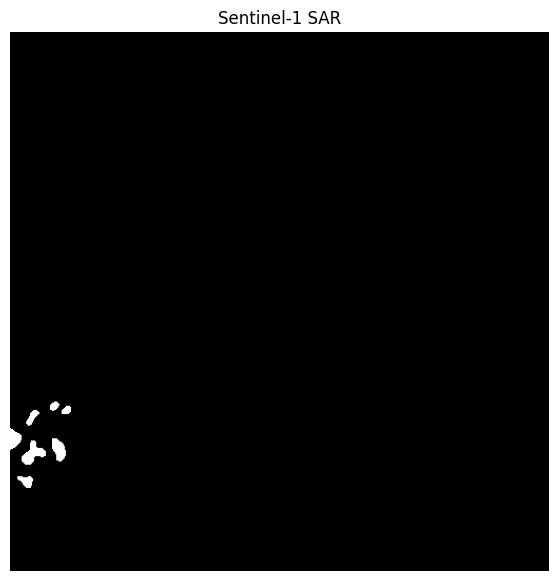

In [ ]:
src = rasterio.open(sar_files[0])
img = src.read()
print("Shape:", img.shape)
print("CRS:", src.crs)
print("Bounds:", src.bounds)

plt.figure(figsize=(7, 7))
plt.imshow(img[0], cmap="gray")
plt.axis("off")
plt.title("Sentinel-1 SAR")
plt.show()

if img.shape[0] >= 2:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img[0], cmap="gray")
    plt.axis("off")
    plt.title("Band 1")

    plt.subplot(1, 2, 2)
    plt.imshow(img[1], cmap="gray")
    plt.axis("off")
    plt.title("Band 2")

    plt.show()

# Inspect flood mask

(array([228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240,
       241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253,
       254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266,
       267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279,
       280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292,
       293, 294, 295, 296, 297, 298], dtype=int16), array([   40,  3364,  9033,  4842,  1040,   735,   674,   874,  1709,
       14320, 32223, 16326,  8453,  8269,  8156,  6723,  4854,  3946,
        3924,  3190,  2852,  2694,  2397,  2414,  2314,  2514,  2708,
        2712,  2857,  3416,  3309,  3162,  3267,  3148,  3136,  3239,
        3623,  3471,  3399,  3627,  3729,  3515,  3451,  3231,  3053,
        2749,  2956,  3078,  2949,  3051,  3318,  3440,  3386,  3549,
        3285,  2874,  2696,  2336,  2032,  2023,  1729,  1574,  1275,
        1143,  1096,   886,   534,   199,    36,    12,     5]))


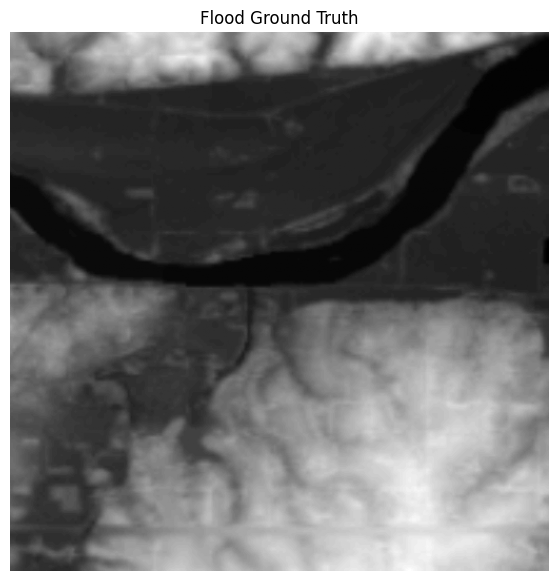

In [ ]:
msk=rasterio.open(mask_files[0]).read(1)
print(np.unique(msk,return_counts=True))
plt.figure(figsize=(7,7));plt.imshow(msk,cmap="gray");plt.axis("off");plt.title("Flood Ground Truth");plt.show()

# Define exact dataset paths

In [ ]:
BASE="/content/Sen1Floods11/sen1floods11_v1.1"
SAR_DIR=f"{BASE}/data/S1GRDHand"
MASK_DIR=f"{BASE}/data/LabelHand"
SPLIT_DIR=f"{BASE}/splits"
sar_files=sorted(glob.glob(f"{SAR_DIR}/*.tif"))
mask_files=sorted(glob.glob(f"{MASK_DIR}/*.tif"))
print("SAR:",len(sar_files),"Masks:",len(mask_files))

SAR: 446 Masks: 446


# Correctly match SAR and masks

In [ ]:
def get_id(p):return os.path.basename(p).split("_")[0]+"_"+os.path.basename(p).split("_")[1]
sar_dict={get_id(x):x for x in sar_files}
mask_dict={get_id(x):x for x in mask_files}
pairs=[(sar_dict[k],mask_dict[k]) for k in sar_dict if k in mask_dict]
print("Matched pairs:",len(pairs))

Matched pairs: 446


# Inspect SAR + mask together

In [ ]:
sar_path,mask_path=pairs[0]
with rasterio.open(sar_path) as s:sar=s.read()
with rasterio.open(mask_path) as m:mask=m.read(1)
print("SAR:",sar.shape,"Mask:",mask.shape)
print("SAR range:",np.nanmin(sar),np.nanmax(sar))
print("Mask values:",np.unique(mask,return_counts=True))

SAR: (2, 512, 512) Mask: (512, 512)
SAR range: -48.24836 -0.69059896
Mask values: (array([-1,  0,  1], dtype=int16), array([174067,  52715,  35362]))


# Visualization

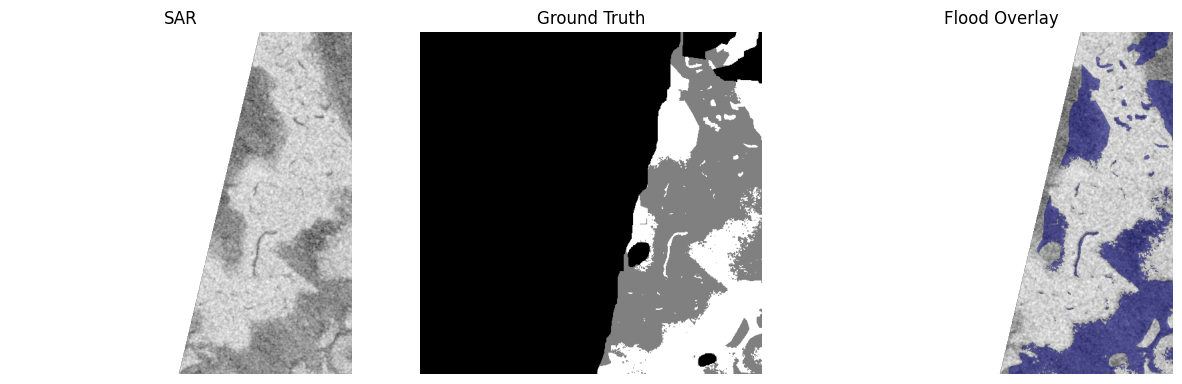

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(sar[0],cmap="gray");ax[0].set_title("SAR")
ax[1].imshow(mask,cmap="gray");ax[1].set_title("Ground Truth")
ax[2].imshow(sar[0],cmap="gray");ax[2].imshow(np.ma.masked_where(mask!=1,mask),alpha=.5,cmap="jet");ax[2].set_title("Flood Overlay")
for a in ax:a.axis("off")
plt.show()

# Load official train/validation/test splits

In [ ]:
def read_split(name):
    p=f"{SPLIT_DIR}/flood_{name}_data.txt"
    with open(p) as f:return [x.strip() for x in f if x.strip()]
train_ids=read_split("train")
val_ids=read_split("valid")
test_ids=read_split("test")
print("Train:",len(train_ids),"Val:",len(val_ids),"Test:",len(test_ids))

Train: 252 Val: 89 Test: 90


# Build split pairs

In [ ]:
def split_pairs(ids):
    out=[]
    for k in ids:
        if k in sar_dict and k in mask_dict:out.append((sar_dict[k],mask_dict[k]))
    return out
train_pairs=split_pairs(train_ids)
val_pairs=split_pairs(val_ids)
test_pairs=split_pairs(test_ids)
print(len(train_pairs),len(val_pairs),len(test_pairs))

252 89 90


# SAR preprocessing

In [ ]:
def normalize_sar(x):
    x = x.astype(np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    out = np.zeros_like(x)
    for i in range(x.shape[0]):
        lo, hi = np.percentile(x[i], [2, 98])
        out[i] = np.clip((x[i] - lo) / (hi - lo + 1e-8), 0, 1)
    return out

# Create 256×256 patches

In [ ]:
def make_patches(pair):
    sp, mp = pair
    with rasterio.open(sp) as s: x = s.read()
    with rasterio.open(mp) as m: y = m.read(1)
    x = normalize_sar(x)
    y = (y == 1).astype(np.float32)
    xs = []; ys = []
    H, W = x.shape[-2], x.shape[-1]

    # if image is smaller than 256, pad it
    if H < 256 or W < 256:
        pad_h = max(0, 256 - H)
        pad_w = max(0, 256 - W)
        x = np.pad(x, ((0,0),(0,pad_h),(0,pad_w)), mode='reflect')
        y = np.pad(y, ((0,pad_h),(0,pad_w)), mode='reflect')
        H, W = x.shape[-2], x.shape[-1]

    for r in range(0, H - 255, 256):
        for c in range(0, W - 255, 256):
            patch_x = x[:, r:r+256, c:c+256]
            patch_y = y[r:r+256, c:c+256]
            if patch_x.shape[-2] == 256 and patch_x.shape[-1] == 256:
                xs.append(patch_x); ys.append(patch_y)

    # safety: if still empty, take top-left crop
    if len(xs) == 0:
        patch_x = x[:, :256, :256]
        patch_y = y[:256, :256]
        xs.append(patch_x); ys.append(patch_y)

    return xs, ys

# PyTorch Dataset

In [ ]:
import torch
from torch.utils.data import Dataset,DataLoader
from tqdm.auto import tqdm
import numpy as np
import random

In [ ]:
class FloodDataset(Dataset):
    def __init__(self,pairs,augment=False):
        self.items=[]
        self.augment=augment
        for p in tqdm(pairs):
            xs,ys=make_patches(p)
            for x,y in zip(xs,ys):
                self.items.append((x,y))
    def __len__(self):return len(self.items)
    def __getitem__(self,i):
        x,y=self.items[i]
        if self.augment:
          if random.random()<.5:x=x[:,:,::-1].copy();y=y[:,::-1].copy()   # horizontal flip
          if random.random()<.5:x=x[:,::-1,:].copy();y=y[::-1,:].copy()   # vertical flip
        x=torch.tensor(x,dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(0)   # (1, H, W)
        return x,y

In [ ]:
NUM_WORKERS=0

train_ds=FloodDataset(train_pairs,True)
val_ds=FloodDataset(val_pairs)
test_ds=FloodDataset(test_pairs)

train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=0,pin_memory=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True)
test_loader=DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True)

print("Train patches:",len(train_ds))
print("Val patches:",len(val_ds))
print("Test patches:",len(test_ds))

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/89 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train patches: 1008
Val patches: 356
Test patches: 360


# Create datasets

In [ ]:
train_ds=FloodDataset(train_pairs,True)
val_ds=FloodDataset(val_pairs)
test_ds=FloodDataset(test_pairs)
print("Train patches:",len(train_ds))
print("Val patches:",len(val_ds))
print("Test patches:",len(test_ds))

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/89 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train patches: 1008
Val patches: 356
Test patches: 360


# DataLoaders

In [ ]:
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
test_loader=DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)

# Check batch

In [ ]:
x,y=next(iter(train_loader))
print("Image:",x.shape,"Mask:",y.shape)

Image: torch.Size([8, 2, 256, 256]) Mask: torch.Size([8, 1, 256, 256])


# U-Net with ResNet50

In [ ]:
model=smp.Unet(encoder_name="resnet50",encoder_weights="imagenet",in_channels=2,classes=1,activation=None).to(DEVICE)
print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

# Dice loss

In [ ]:
class DiceLoss(nn.Module):
    def forward(self,p,t):
        p=torch.sigmoid(p)
        p=p.view(p.size(0),-1);t=t.view(t.size(0),-1)
        inter=(p*t).sum(1)
        return (1-(2*inter+1)/(p.sum(1)+t.sum(1)+1)).mean()
dice_loss=DiceLoss()
bce_loss=nn.BCEWithLogitsLoss()
def loss_fn(p,t):return bce_loss(p,t)+dice_loss(p,t)

# Optimizer

In [ ]:
optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)

# Metrics

In [ ]:
def metrics(pred,target):
    pred=(torch.sigmoid(pred)>.5).int().cpu().numpy().ravel()
    target=target.int().cpu().numpy().ravel()
    return jaccard_score(target,pred,zero_division=0),f1_score(target,pred,zero_division=0),precision_score(target,pred,zero_division=0),recall_score(target,pred,zero_division=0)

# Validation

In [ ]:
def validate():
    model.eval(); ls = []; all_p = []; all_y = []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            p = model(x)
            ls.append(loss_fn(p, y).item())
            all_p.append((torch.sigmoid(p) > .5).int().cpu().numpy())
            all_y.append(y.int().cpu().numpy())
    all_p = np.concatenate(all_p).ravel()
    all_y = np.concatenate(all_y).ravel()
    iou = jaccard_score(all_y, all_p, zero_division=0)
    f1  = f1_score(all_y, all_p, zero_division=0)
    prec = precision_score(all_y, all_p, zero_division=0)
    rec  = recall_score(all_y, all_p, zero_division=0)
    return np.mean(ls), (iou, f1, prec, rec)

# Training

In [ ]:
history={"train_loss":[],"val_loss":[],"iou":[],"f1":[]}
best=0
for e in range(EPOCHS):
    model.train();run=0
    for x,y in tqdm(train_loader,desc=f"Epoch {e+1}/{EPOCHS}"):
        x,y=x.to(DEVICE),y.to(DEVICE)
        optimizer.zero_grad();p=model(x);loss=loss_fn(p,y);loss.backward();optimizer.step();run+=loss.item()
    vl,m=validate();scheduler.step()
    history["train_loss"].append(run/len(train_loader));history["val_loss"].append(vl);history["iou"].append(m[0]);history["f1"].append(m[1])
    print(f"Epoch {e+1}: Train={run/len(train_loader):.4f} Val={vl:.4f} IoU={m[0]:.4f} F1={m[1]:.4f}")
    if m[0]>best:
        best=m[0];torch.save(model.state_dict(),"best_unet_resnet50.pth")

Epoch 1/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 1: Train=1.5193 Val=1.2994 IoU=0.3841 F1=0.5551


Epoch 2/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 2: Train=1.2554 Val=1.1282 IoU=0.5098 F1=0.6753


Epoch 3/15:   0%|          | 0/126 [00:00<?, ?it/s]

...

Epoch 13: Train=0.8530 Val=0.8940 IoU=0.5454 F1=0.7058


Epoch 14/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 14: Train=0.8400 Val=0.8984 IoU=0.5468 F1=0.7070


Epoch 15/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 15: Train=0.8395 Val=0.8926 IoU=0.5503 F1=0.7099


# Plot training

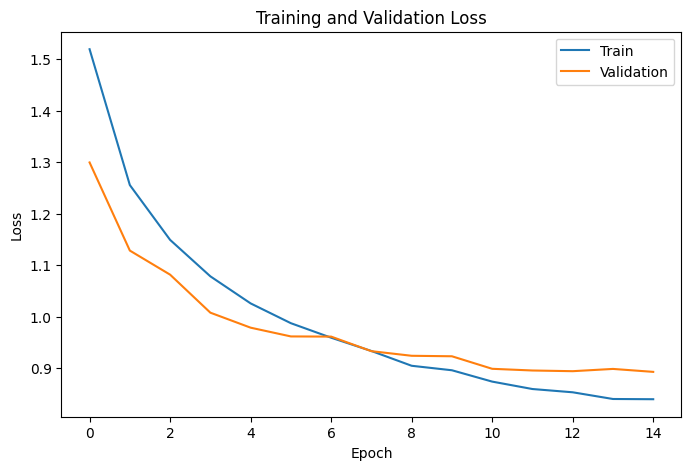

In [ ]:
plt.figure(figsize=(8,5));plt.plot(history["train_loss"],label="Train")
plt.plot(history["val_loss"],label="Validation")
plt.xlabel("Epoch");plt.ylabel("Loss")
plt.legend();plt.title("Training and Validation Loss")
plt.show()

# Plot IoU

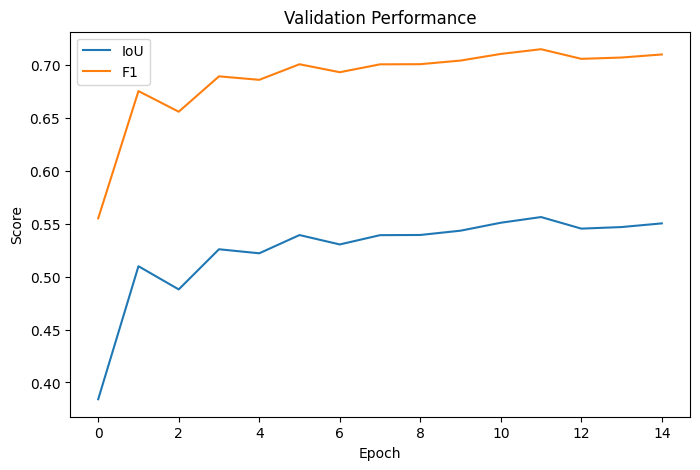

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history["iou"],label="IoU")
plt.plot(history["f1"],label="F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Validation Performance")
plt.show()

# Load best model

In [ ]:
model.load_state_dict(torch.load("best_unet_resnet50.pth",map_location=DEVICE))
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

# Test evaluation

In [ ]:
ys=[];ps=[]
with torch.no_grad():
    for x,y in tqdm(test_loader):
        p=torch.sigmoid(model(x.to(DEVICE))).cpu().numpy()
        ps.append(p);ys.append(y.numpy())
ps = (np.concatenate(ps).ravel() > .5).astype(int)
ys = np.concatenate(ys).ravel().astype(int)
print("IoU:",jaccard_score(ys,ps,zero_division=0))
print("F1:",f1_score(ys,ps,zero_division=0))
print("Precision:",precision_score(ys,ps,zero_division=0))
print("Recall:",recall_score(ys,ps,zero_division=0))

  0%|          | 0/45 [00:00<?, ?it/s]

IoU: 0.5678427659473108
F1: 0.7243618789849923
Precision: 0.7064524170865757
Recall: 0.7432030150021375


# Confusion matrix

In [ ]:
cm=confusion_matrix(ys,ps)
print(cm)

[[20234400   792459]
 [  658967  1907134]]


# Prediction visualization

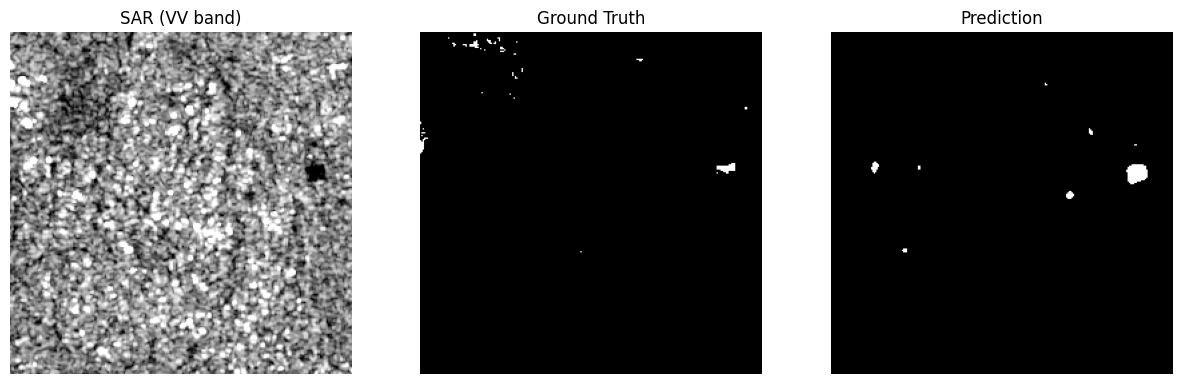

In [ ]:
x, y = test_ds[random.randrange(len(test_ds))]
with torch.no_grad():
    p = torch.sigmoid(model(x.unsqueeze(0).to(DEVICE))).cpu().squeeze().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(x[0].numpy(), cmap="gray"); ax[0].set_title("SAR (VV band)")
ax[1].imshow(y.squeeze().numpy(), cmap="gray"); ax[1].set_title("Ground Truth")
ax[2].imshow(p > .5, cmap="gray"); ax[2].set_title("Prediction")
for a in ax: a.axis("off")
plt.show()

# Prediction overlay

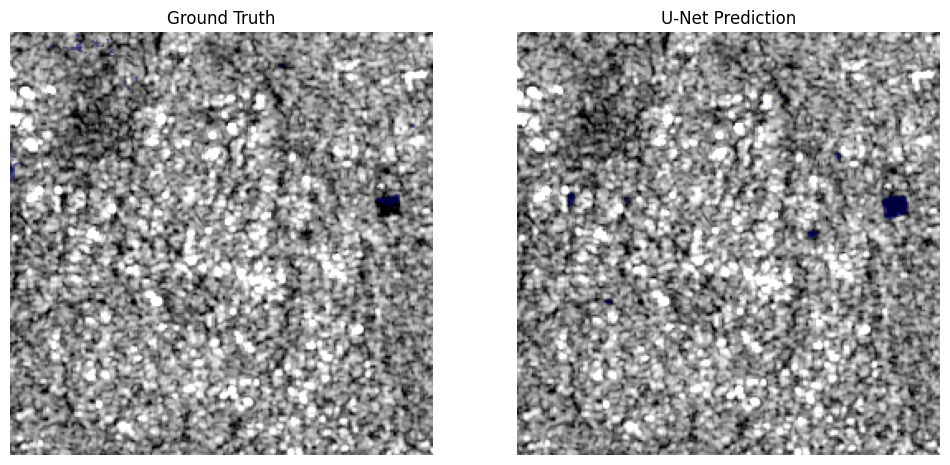

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(x[0].numpy(), cmap="gray")
ax[0].imshow(np.ma.masked_where(y.squeeze()==0, y.squeeze()), alpha=.5, cmap="jet")
ax[0].set_title("Ground Truth")
ax[1].imshow(x[0].numpy(), cmap="gray")
ax[1].imshow(np.ma.masked_where(p<=.5, p>.5), alpha=.5, cmap="jet")
ax[1].set_title("U-Net Prediction")
for a in ax: a.axis("off")
plt.show()

# Threshold baseline

In [ ]:
def threshold_predict(x,t=.5):return (x<t).astype(np.uint8)

# Find best threshold

In [ ]:
vals = np.linspace(.05, .95, 19)
scores = []
for t in vals:
    pp = []; tt = []
    for x, y in val_ds:
        pp.extend(threshold_predict(x[0].numpy(), t).ravel())   # x[0] = VV band only
        tt.extend(y.squeeze().numpy().ravel())
    scores.append(jaccard_score(tt, pp, zero_division=0))
best_t = vals[np.argmax(scores)]
print("Best threshold:", best_t, "Validation IoU:", max(scores))

Best threshold: 0.3 Validation IoU: 0.21607927606988642


# Threshold test performance

In [ ]:
pp = []; tt = []
for x, y in test_ds:
    pp.extend(threshold_predict(x[0].numpy(), best_t).ravel())   # x[0] = VV band only
    tt.extend(y.squeeze().numpy().ravel())
print("Threshold IoU:", jaccard_score(tt, pp, zero_division=0))
print("Threshold F1:", f1_score(tt, pp, zero_division=0))
print("Threshold Precision:", precision_score(tt, pp, zero_division=0))
print("Threshold Recall:", recall_score(tt, pp, zero_division=0))

Threshold IoU: 0.22976598524196473
Threshold F1: 0.37367432178042675
Threshold Precision: 0.3049502277180135
Threshold Recall: 0.48238553353901503


In [ ]:
import gc

# Delete U-Net from memory
del model
del train_ds, val_ds, test_ds
del train_loader, val_loader, test_loader
torch.cuda.empty_cache()
gc.collect()

print("RAM freed")

RAM freed


In [ ]:
train_ds = FloodDataset(train_pairs, True)
val_ds   = FloodDataset(val_pairs)
test_ds  = FloodDataset(test_pairs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Train patches:", len(train_ds))
print("Val patches:",   len(val_ds))
print("Test patches:",  len(test_ds))

  0%|          | 0/252 [00:00<?, ?it/s]

  0%|          | 0/89 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train patches: 1008
Val patches: 356
Test patches: 360


# Define and train UNet++

In [ ]:
# UNet++ with ResNet50 (attention-based)
model_att = smp.UnetPlusPlus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=2,
    classes=1,
    activation=None
).to(DEVICE)

optimizer_att = torch.optim.AdamW(model_att.parameters(), lr=LR, weight_decay=1e-4)
scheduler_att = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_att, T_max=EPOCHS)

history_att = {"train_loss": [], "val_loss": [], "iou": [], "f1": []}
best_att = 0

for e in range(EPOCHS):
    model_att.train(); run = 0
    for x, y in tqdm(train_loader, desc=f"Epoch {e+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer_att.zero_grad(); p = model_att(x); loss = loss_fn(p, y)
        loss.backward(); optimizer_att.step(); run += loss.item()

    # reuse same validate() but temporarily swap model
    model_att.eval(); ls = []; all_p = []; all_y = []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            p = model_att(x)
            ls.append(loss_fn(p, y).item())
            all_p.append((torch.sigmoid(p) > .5).int().cpu().numpy())
            all_y.append(y.int().cpu().numpy())
    all_p = np.concatenate(all_p).ravel()
    all_y_v = np.concatenate(all_y).ravel()
    iou = jaccard_score(all_y_v, all_p, zero_division=0)
    f1  = f1_score(all_y_v, all_p, zero_division=0)
    vl  = np.mean(ls)
    scheduler_att.step()

    history_att["train_loss"].append(run/len(train_loader))
    history_att["val_loss"].append(vl)
    history_att["iou"].append(iou)
    history_att["f1"].append(f1)
    print(f"Epoch {e+1}: Train={run/len(train_loader):.4f} Val={vl:.4f} IoU={iou:.4f} F1={f1:.4f}")
    if iou > best_att:
        best_att = iou
        torch.save(model_att.state_dict(), "best_unetpp_resnet50.pth")

Epoch 1/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 1: Train=1.3690 Val=1.1932 IoU=0.5069 F1=0.6728


Epoch 2/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 2: Train=1.1509 Val=1.0607 IoU=0.5228 F1=0.6866


Epoch 3/15:   0%|          | 0/126 [00:00<?, ?it/s]

...

Epoch 13: Train=0.8012 Val=0.8758 IoU=0.5476 F1=0.7077


Epoch 14/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 14: Train=0.7960 Val=0.8668 IoU=0.5551 F1=0.7139


Epoch 15/15:   0%|          | 0/126 [00:00<?, ?it/s]

Epoch 15: Train=0.7936 Val=0.8804 IoU=0.5518 F1=0.7111


# Test evaluation for UNet++

In [ ]:
# Test evaluation — UNet++
model_att.load_state_dict(torch.load("best_unetpp_resnet50.pth", map_location=DEVICE))
model_att.eval()

ys_att = []; ps_att = []
with torch.no_grad():
    for x, y in tqdm(test_loader):
        p = torch.sigmoid(model_att(x.to(DEVICE))).cpu().numpy()
        ps_att.append(p); ys_att.append(y.numpy())

ps_att = (np.concatenate(ps_att).ravel() > .5).astype(int)
ys_att = np.concatenate(ys_att).ravel().astype(int)

print("UNet++ IoU:",       jaccard_score(ys_att, ps_att, zero_division=0))
print("UNet++ F1:",        f1_score(ys_att, ps_att, zero_division=0))
print("UNet++ Precision:", precision_score(ys_att, ps_att, zero_division=0))
print("UNet++ Recall:",    recall_score(ys_att, ps_att, zero_division=0))

  0%|          | 0/45 [00:00<?, ?it/s]

UNet++ IoU: 0.5726892138459794
UNet++ F1: 0.7282929250153368
UNet++ Precision: 0.6689417780248054
UNet++ Recall: 0.7992012005762829


# Plot UNet++ training curves

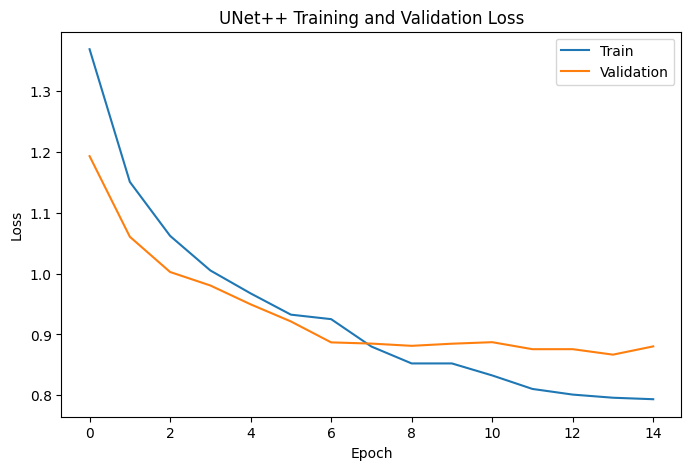

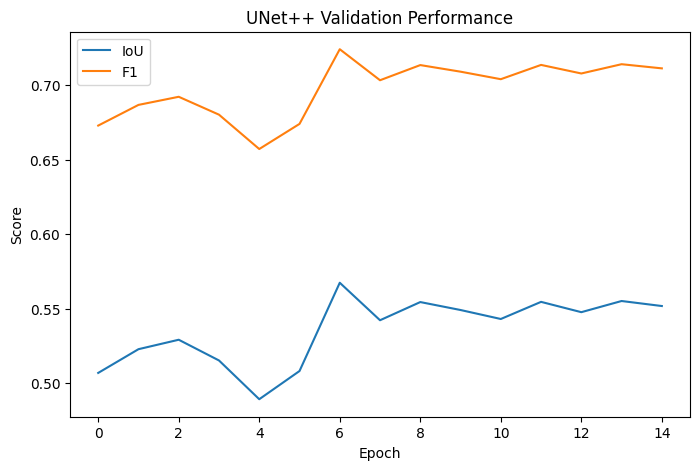

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_att["train_loss"], label="Train")
plt.plot(history_att["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.title("UNet++ Training and Validation Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_att["iou"], label="IoU")
plt.plot(history_att["f1"], label="F1")
plt.xlabel("Epoch"); plt.ylabel("Score")
plt.legend(); plt.title("UNet++ Validation Performance")
plt.show()

# Final comparison table

In [ ]:
# U-Net results from earlier run (hardcoded since model was cleared from memory)
unet_iou = 0.570642
unet_f1  = 0.726635
unet_p   = 0.694015
unet_r   = 0.762473

base_iou = 0.229766
base_f1  = 0.373674
base_p   = 0.304950
base_r   = 0.482386

# UNet++ results from current run
att_iou = jaccard_score(ys_att, ps_att, zero_division=0)
att_f1  = f1_score(ys_att, ps_att, zero_division=0)
att_p   = precision_score(ys_att, ps_att, zero_division=0)
att_r   = recall_score(ys_att, ps_att, zero_division=0)

results = pd.DataFrame({
    "Model":     ["SAR Threshold", "U-Net ResNet50", "UNet++ ResNet50"],
    "IoU":       [base_iou, unet_iou, att_iou],
    "F1":        [base_f1,  unet_f1,  att_f1],
    "Precision": [base_p,   unet_p,   att_p],
    "Recall":    [base_r,   unet_r,   att_r]
})
results

,Model,IoU,F1,Precision,Recall
0,SAR Threshold,0.229766,0.373674,0.304950,0.482386
1,U-Net ResNet50,0.570642,0.726635,0.694015,0.762473
2,UNet++ ResNet50,0.572689,0.728293,0.668942,0.799201


# Save results

In [ ]:
results.to_csv("flood_mapping_results.csv", index=False)
torch.save(model_att.state_dict(), "Sen1Floods11_UNet_ResNet50.pth")
print("Saved!")

Saved!


# Download results

In [ ]:
from google.colab import files
files.download("flood_mapping_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>